In [1]:
from SCFT_DNA.SCFT_functions import *
from SCFT_DNA.DNA_input import *

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

#import hictkpy as htk
from matplotlib.colors import LogNorm

from pathlib import Path

from Bead_sequence_MC.mf_chromatin_functions import *


Using numpy


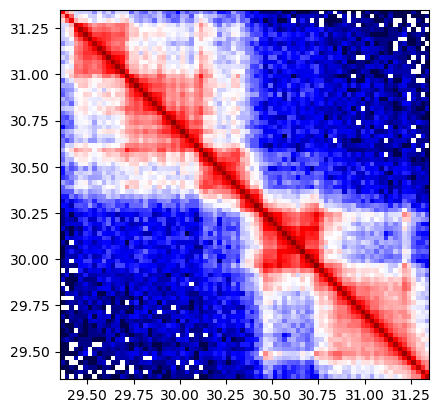

In [2]:
HiC = np.load("../Bead_sequence_MC/chr21_2935_3135.npy")
extent = (29.35,31.35,29.35,31.35)
plt.imshow(HiC, norm=LogNorm(),cmap="seismic",extent=extent)

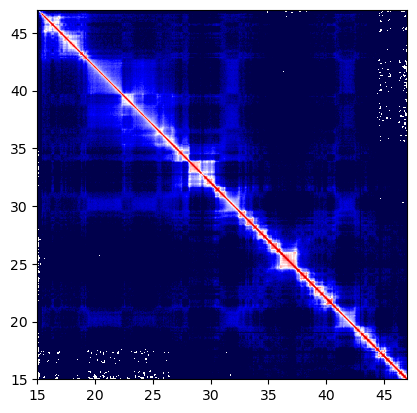

In [3]:
HiC = np.load("chr21_15_47.npy")
extent = (15, 47, 15, 47)
plt.imshow(HiC, norm=LogNorm(), cmap="seismic", extent=extent)


In [5]:
dense_to_cool("IMR90_temp.cool", HiC, bin_size=25_000)

In [6]:
import cooler
import cooltools
import bioframe
import pandas as pd

# Load a balanced Hi-C map in .cool/.mcool format
clr = cooler.Cooler("IMR90_temp.cool")

bias, stats = cooler.balance_cooler(
    clr,
    store=True,
    store_name="weight",   # this is the default, but explicit is fine
    ignore_diags=2,        # default behavior; adjust if needed
)

# re-open to ensure the new column is visible
clr = cooler.Cooler("IMR90_temp.cool")
print(clr.bins()[:].columns)  # should include "weight"

view_df = bioframe.make_viewframe(clr.chromsizes)

eigvals, eigvecs = cooltools.eigs_cis(
    clr,
    view_df=view_df,
    n_eigs=3,
    # no phasing_track
)

E1 = eigvecs[["chrom", "start", "end", "E1"]]

E1 = eigvecs[["chrom", "start", "end", "E1"]].copy()

# Pick the chromosome (adjust if your .cool uses a different chrom name)
chrom = E1["chrom"].iloc[0]
d = E1[E1["chrom"] == chrom].copy()

# x-position = bin midpoint
x = 0.5 * (d["start"].to_numpy() + d["end"].to_numpy())
y = -d["E1"].to_numpy()

window = 5  # in bins; try 5–25 depending on resolution
y_smooth = pd.Series(y).rolling(window=window, center=True, min_periods=1).mean().to_numpy()



Index(['chrom', 'start', 'end', 'weight'], dtype='object')


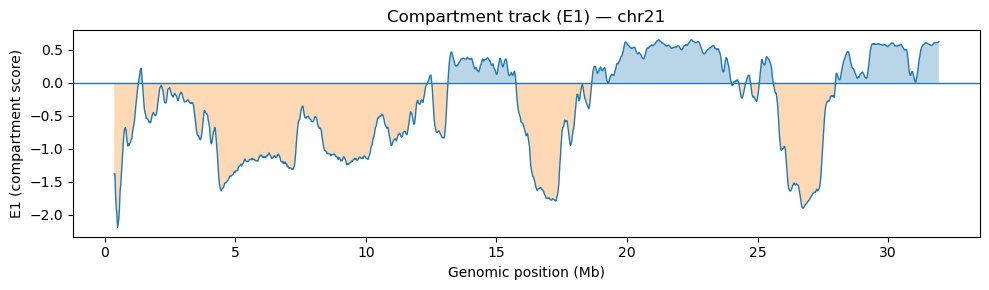

In [17]:
x_mb = x / 1e6

plt.figure(figsize=(10, 3))
plt.plot(x_mb, y_smooth, linewidth=1.0)
plt.axhline(0, linewidth=1.0)

# Fill above/below zero to highlight compartments
plt.fill_between(x_mb, 0, y_smooth, where=(y_smooth >= 0), alpha=0.3)
plt.fill_between(x_mb, 0, y_smooth, where=(y_smooth < 0), alpha=0.3)

plt.xlabel("Genomic position (Mb)")
plt.ylabel("E1 (compartment score)")
plt.title(f"Compartment track (E1) — {chrom}")
plt.tight_layout()
plt.show()


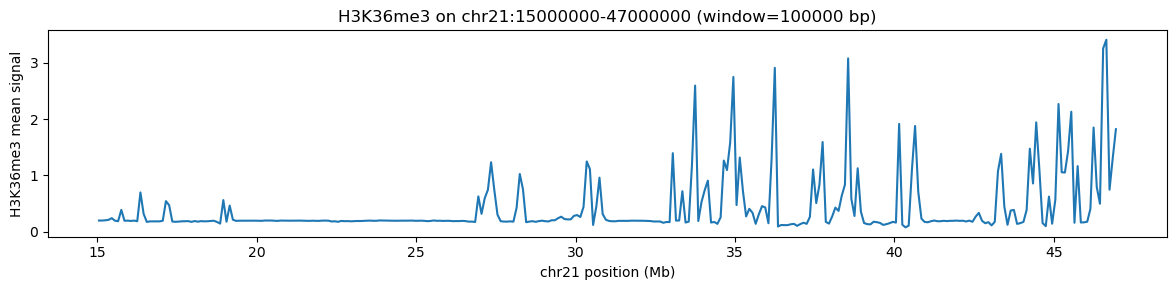

In [275]:
import numpy as np
import pyBigWig
import matplotlib.pyplot as plt

bw_path = "ENCFF187AAC.bigWig"   # your downloaded ENCODE bigWig
chrom = "chr21"

start_bp = 15_000_000
end_bp   = 47_000_000         # adjust to what you want
step_bp  = 100000#150000#             # 10 kb windows

bw = pyBigWig.open(bw_path)

starts = np.arange(start_bp, end_bp, step_bp, dtype=int)
ends   = np.minimum(starts + step_bp, end_bp)

# mean signal in each [start, end) window
signal = np.array([
    (bw.stats(chrom, int(s), int(e), type="mean")[0] or np.nan)
    for s, e in zip(starts, ends)
], dtype=float)

bw.close()

x_mb_epi = (starts + ends) / 2 / 1e6  # window midpoints in Mb

plt.figure(figsize=(12, 3))
plt.plot(x_mb_epi, signal)
plt.xlabel("chr21 position (Mb)")
plt.ylabel("H3K36me3 mean signal")
plt.title(f"H3K36me3 on {chrom}:{start_bp}-{end_bp} (window={step_bp} bp)")
plt.tight_layout()
plt.show()

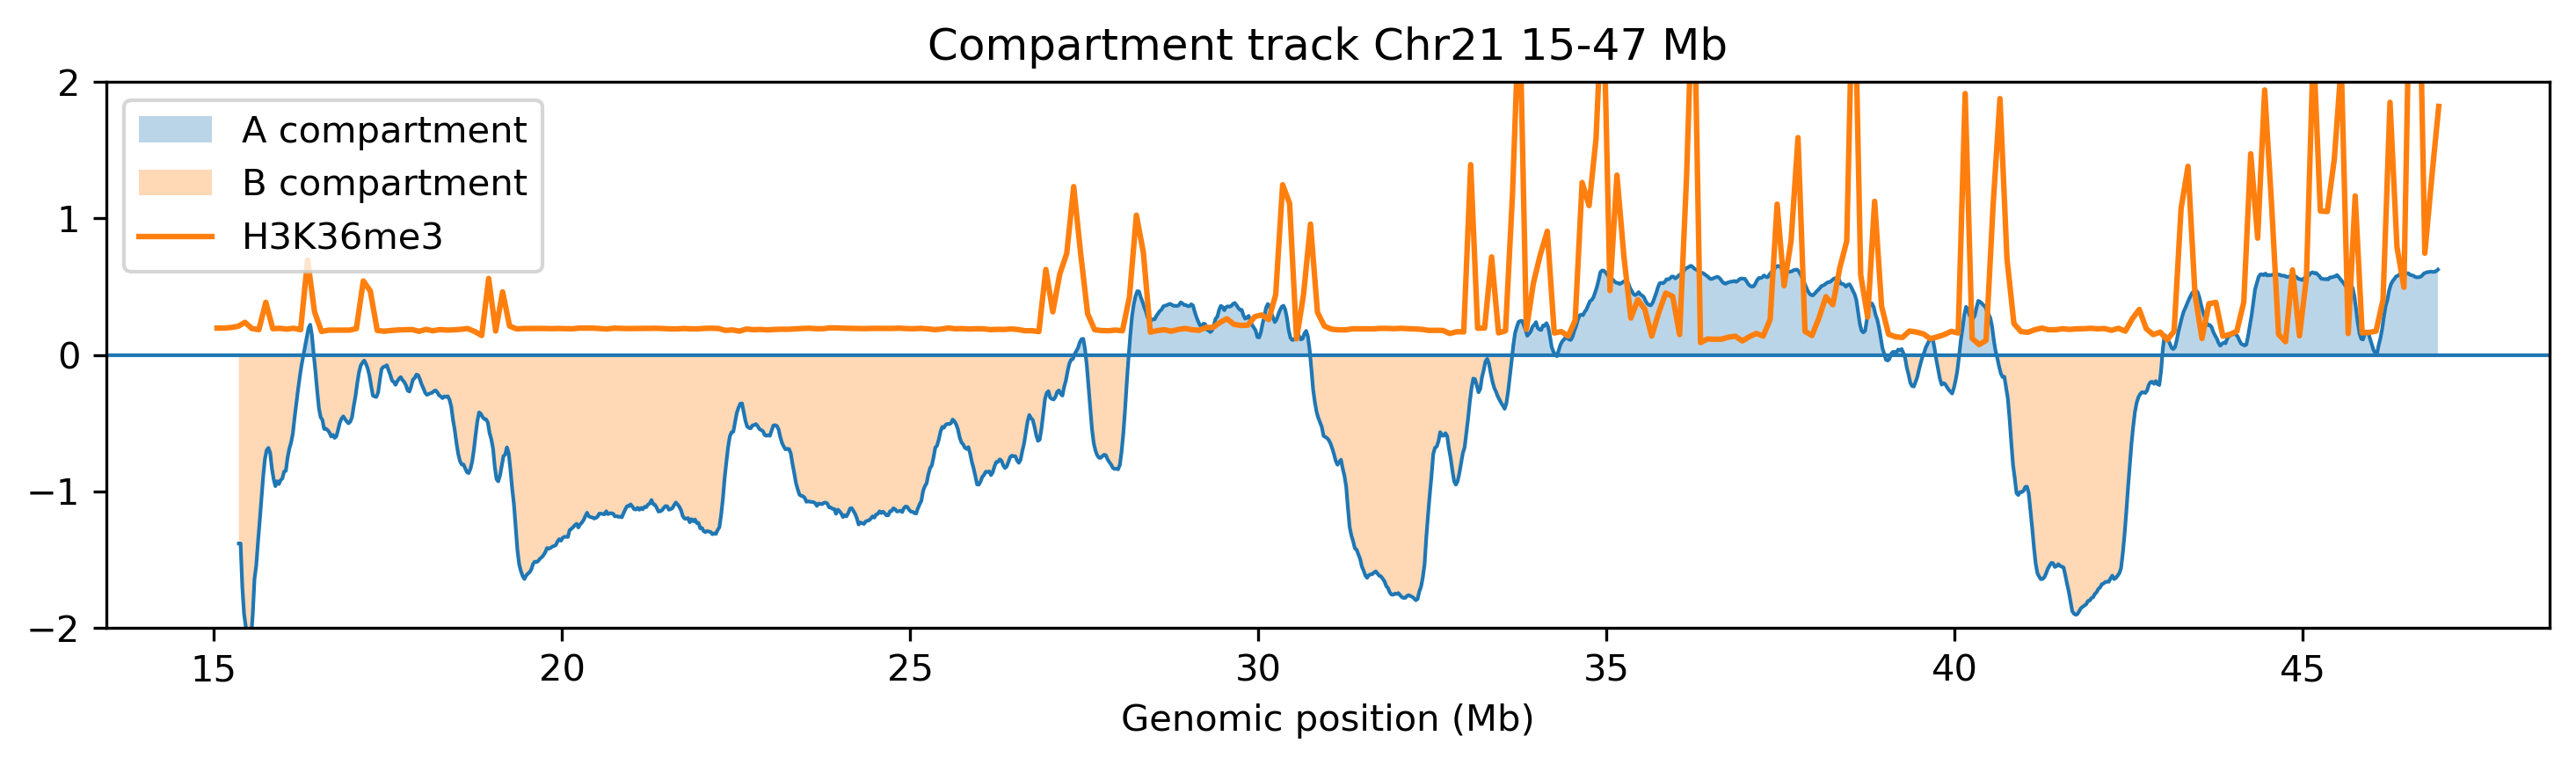

In [276]:
x_mb =15+ x / 1e6

plt.figure(figsize=(10, 3), dpi = 300)
plt.plot(x_mb, y_smooth, linewidth=1.0)
plt.axhline(0, linewidth=1.0)

# Fill above/below zero to highlight compartments
plt.fill_between(x_mb, 0, y_smooth, where=(y_smooth >= 0), alpha=0.3, label="A compartment")
plt.fill_between(x_mb, 0, y_smooth, where=(y_smooth < 0), alpha=0.3, label="B compartment")

plt.plot(x_mb_epi, signal, label="H3K36me3")

plt.ylim(-2,2)

plt.xlabel("Genomic position (Mb)")
#plt.ylabel("E1 (compartment score)")
#plt.title(f"Compartment track (E1) — {chrom}")
plt.title(f"Compartment track Chr21 15-47 Mb")
plt.tight_layout()
plt.legend()
plt.show()


In [137]:
print(x_mb_epi.shape)
print(y_smooth.shape)

(214,)
(1280,)


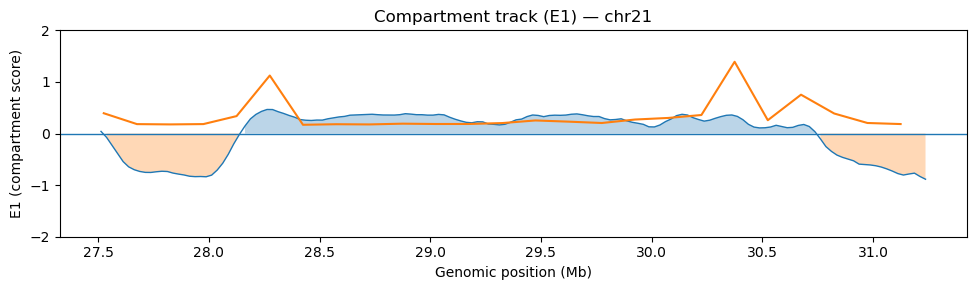

In [138]:
start=500
end = 650

start_epi= int(start * x_mb_epi.shape[0]/y_smooth.shape[0])
end_epi = int(end * x_mb_epi.shape[0]/y_smooth.shape[0])

x_mb =15+ x / 1e6

plt.figure(figsize=(10, 3))
plt.plot(x_mb[start:end], y_smooth[start:end], linewidth=1.0)
plt.axhline(0, linewidth=1.0)

# Fill above/below zero to highlight compartments
plt.fill_between(x_mb[start:end], 0, y_smooth[start:end], where=(y_smooth[start:end] >= 0), alpha=0.3)
plt.fill_between(x_mb[start:end], 0, y_smooth[start:end], where=(y_smooth[start:end] < 0), alpha=0.3)

plt.plot(x_mb_epi[start_epi:end_epi], signal[start_epi:end_epi])

plt.ylim(-2,2)

plt.xlabel("Genomic position (Mb)")
plt.ylabel("E1 (compartment score)")
plt.title(f"Compartment track (E1) — {chrom}")
plt.tight_layout()
plt.show()


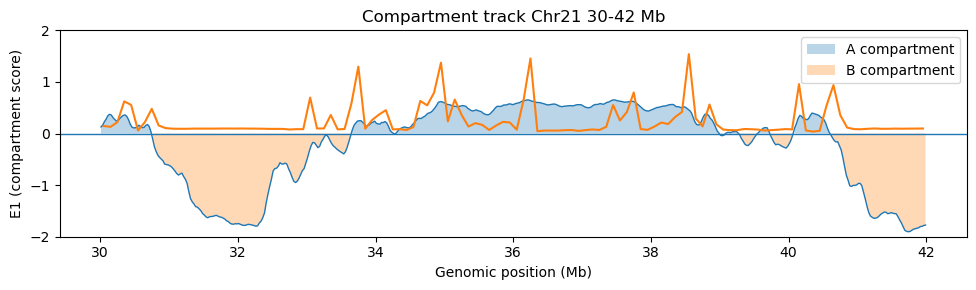

In [277]:
start_mbp = 30
end_mbp = 42
genome_length_mbp = 47-15
start = int(y_smooth.shape[0]*(start_mbp-15)/genome_length_mbp)
end = int(y_smooth.shape[0]*(end_mbp-15)/genome_length_mbp)

start_epi= int(start * x_mb_epi.shape[0]/y_smooth.shape[0])
end_epi = int(end * x_mb_epi.shape[0]/y_smooth.shape[0])

x_mb =15+ x / 1e6

plt.figure(figsize=(10, 3))
plt.plot(x_mb[start:end], y_smooth[start:end], linewidth=1.0)
plt.axhline(0, linewidth=1.0)

# Fill above/below zero to highlight compartments
plt.fill_between(x_mb[start:end], 0, y_smooth[start:end], where=(y_smooth[start:end] >= 0), alpha=0.3, label="A compartment")
plt.fill_between(x_mb[start:end], 0, y_smooth[start:end], where=(y_smooth[start:end] < 0), alpha=0.3, label="B compartment")

plt.plot(x_mb_epi[start_epi:end_epi], signal[start_epi:end_epi]/2)

plt.ylim(-2,2)

plt.xlabel("Genomic position (Mb)")
plt.ylabel("E1 (compartment score)")
plt.title(f"Compartment track Chr21 30-42 Mb")
plt.tight_layout()
#plt.grid()
plt.legend()
plt.show()


(12, 996)


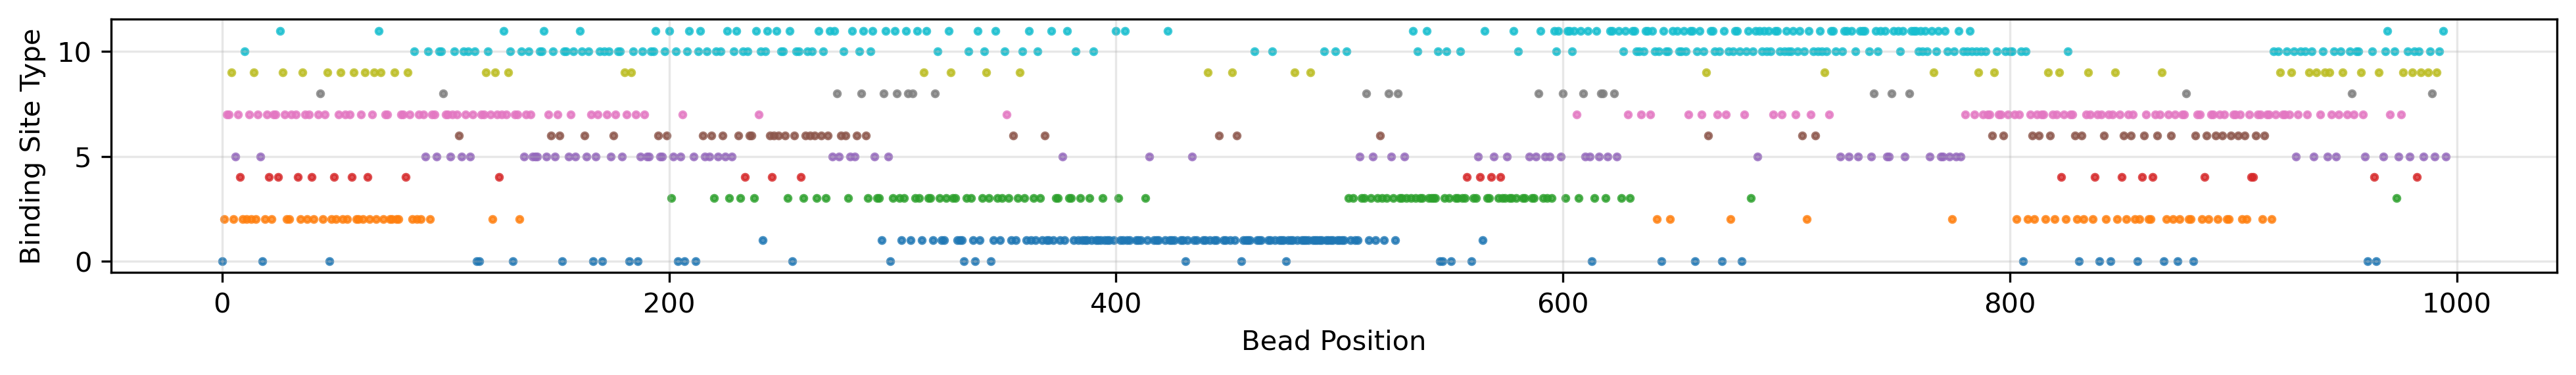

In [278]:
infered_sequence = np.load("../Bead_sequence_MC/IMR90_infer_sequence_30_42.npy")
visualize_config(infered_sequence, np.max(infered_sequence))
chain_interaction_binary = colors_to_onehot(infered_sequence)
ns = chain_interaction_binary.shape[1]-1
print(chain_interaction_binary.shape)

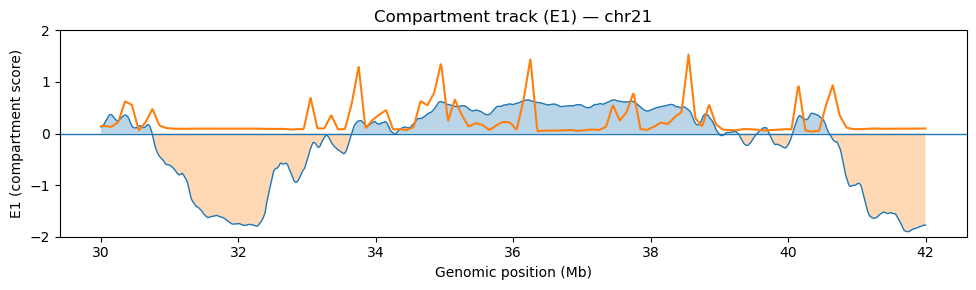

In [279]:
x_uniform_scale = np.linspace(start_mbp, end_mbp, chain_interaction_binary.shape[1])
eigenvector_scaled = np.interp(x_uniform_scale, x_mb[start:end], y_smooth[start:end])
epigenetics_scaled = np.interp(x_uniform_scale, x_mb_epi[start_epi:end_epi], signal[start_epi:end_epi])

plt.figure(figsize=(10, 3))
plt.plot(x_uniform_scale, eigenvector_scaled, linewidth=1.0)
plt.axhline(0, linewidth=1.0)

# Fill above/below zero to highlight compartments
plt.fill_between(x_uniform_scale, 0, eigenvector_scaled, where=(eigenvector_scaled >= 0), alpha=0.3)
plt.fill_between(x_uniform_scale, 0, eigenvector_scaled, where=(eigenvector_scaled < 0), alpha=0.3)

plt.plot(x_uniform_scale, epigenetics_scaled/2)

plt.ylim(-2,2)

plt.xlabel("Genomic position (Mb)")
plt.ylabel("E1 (compartment score)")
plt.title(f"Compartment track (E1) — {chrom}")
plt.tight_layout()
#plt.grid()
plt.show()


[1. 1. 1. 1. 0. 0. 0. 1. 0. 0. 1. 1.]


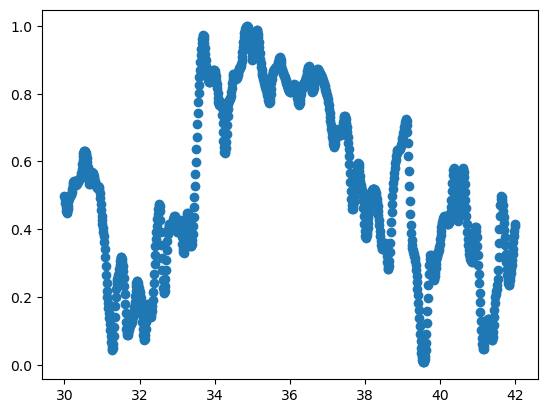

In [280]:
AB_binding_class_eigenvector = np.zeros(chain_interaction_binary.shape[0])
AB_index = np.zeros(chain_interaction_binary.shape[1])
eigen_vector_AB = np.where(eigenvector_scaled>0, 1, -1)
for i in range(chain_interaction_binary.shape[0]):
    integral = np.mean(eigen_vector_AB * chain_interaction_binary[i,:])
    if integral > 0:
        AB_index += chain_interaction_binary[i,:]
        AB_binding_class_eigenvector[i] = 1

from scipy.ndimage import gaussian_filter
AB_index_smooth = gaussian_filter(AB_index,sigma=4)
plt.scatter(x_uniform_scale,AB_index_smooth)

print(AB_binding_class_eigenvector)
np.save("AB_binding_class_eigenvector", AB_binding_class_eigenvector)

[1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1.]


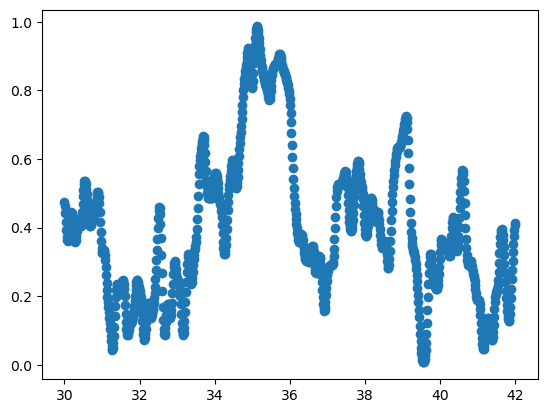

In [282]:
AB_binding_class_epigenetics = np.zeros(chain_interaction_binary.shape[0])
AB_index_epigenetic = np.zeros(chain_interaction_binary.shape[1])
epigenetics_AB = np.where(epigenetics_scaled>0.2, 1, -1)
for i in range(chain_interaction_binary.shape[0]):
    integral = np.mean(epigenetics_AB * chain_interaction_binary[i,:])
    if integral > 0:
        AB_index_epigenetic += chain_interaction_binary[i,:]
        AB_binding_class_epigenetics[i] = 1

AB_index_epigenetic_smooth = gaussian_filter(AB_index_epigenetic,sigma=4)
plt.scatter(x_uniform_scale,AB_index_epigenetic_smooth)
print(AB_binding_class_epigenetics)
np.save("AB_binding_class_epigenetics", AB_binding_class_epigenetics)

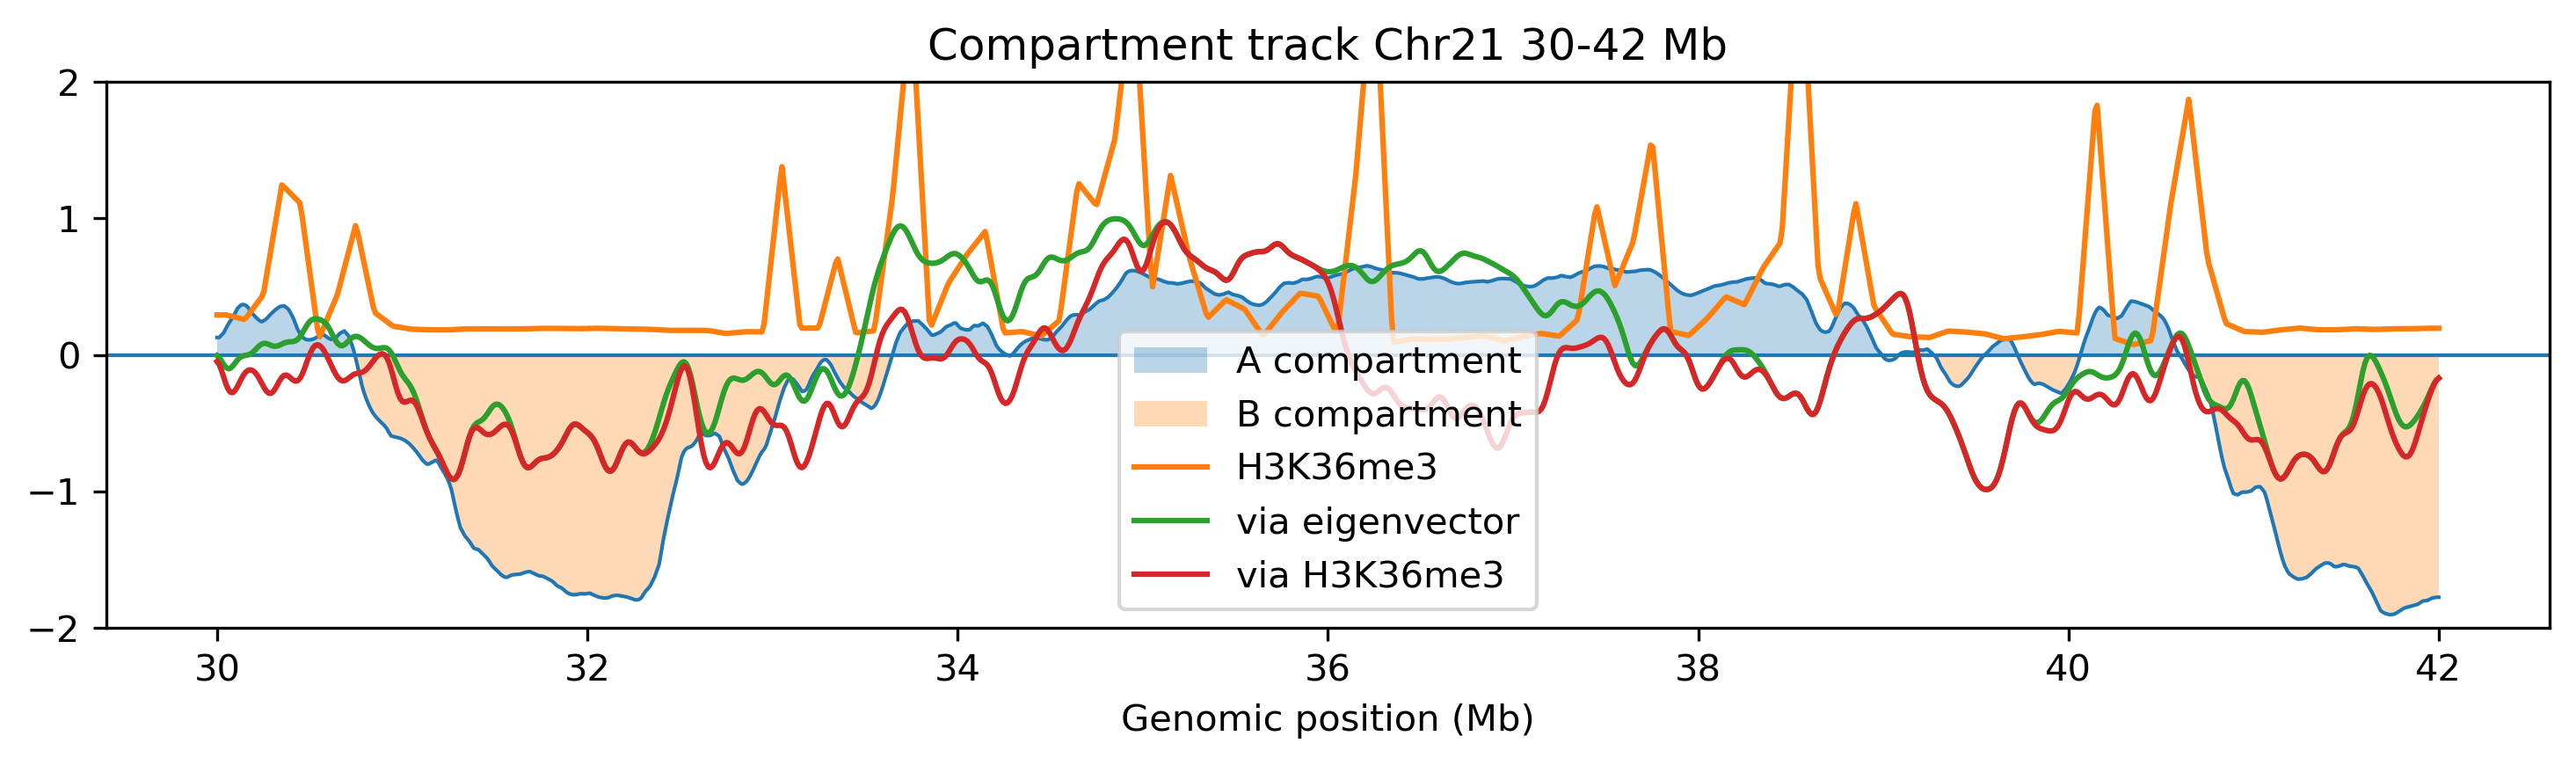

In [283]:
x_uniform_scale = np.linspace(start_mbp, end_mbp, chain_interaction_binary.shape[1])
eigenvector_scaled = np.interp(x_uniform_scale, x_mb[start:end], y_smooth[start:end])
epigenetics_scaled = np.interp(x_uniform_scale, x_mb_epi[start_epi:end_epi], signal[start_epi:end_epi])

plt.figure(figsize=(10, 3), dpi = 300)
plt.plot(x_uniform_scale, eigenvector_scaled, linewidth=1.0)
plt.axhline(0, linewidth=1.0)

# Fill above/below zero to highlight compartments
plt.fill_between(x_uniform_scale, 0, eigenvector_scaled, where=(eigenvector_scaled >= 0), alpha=0.3, label="A compartment")
plt.fill_between(x_uniform_scale, 0, eigenvector_scaled, where=(eigenvector_scaled < 0), alpha=0.3, label="B compartment")

plt.plot(x_uniform_scale, epigenetics_scaled, label = "H3K36me3")

plt.plot(x_uniform_scale,2*AB_index_smooth-1, label="via eigenvector")
plt.plot(x_uniform_scale,2*AB_index_epigenetic_smooth-1, label="via H3K36me3")

#plt.scatter(x_uniform_scale,2*AB_index_smooth-1, s=2, label = "vector")
#plt.scatter(x_uniform_scale,2*AB_index_epigenetic_smooth-1, s=2, label = "epigenetic")
#plt.scatter(x_uniform_scale,eigen_vector_AB, s=2)
#plt.scatter(x_uniform_scale,epigenetics_AB, s=2)
plt.ylim(-2,2)

plt.xlabel("Genomic position (Mb)")
#plt.ylabel("E1 (compartment score)")
plt.title(f"Compartment track Chr21 30-42 Mb")
plt.tight_layout()
#plt.grid()
plt.legend()
plt.show()


Text(0.5, 1.0, 'A/B compartment for binding sites')

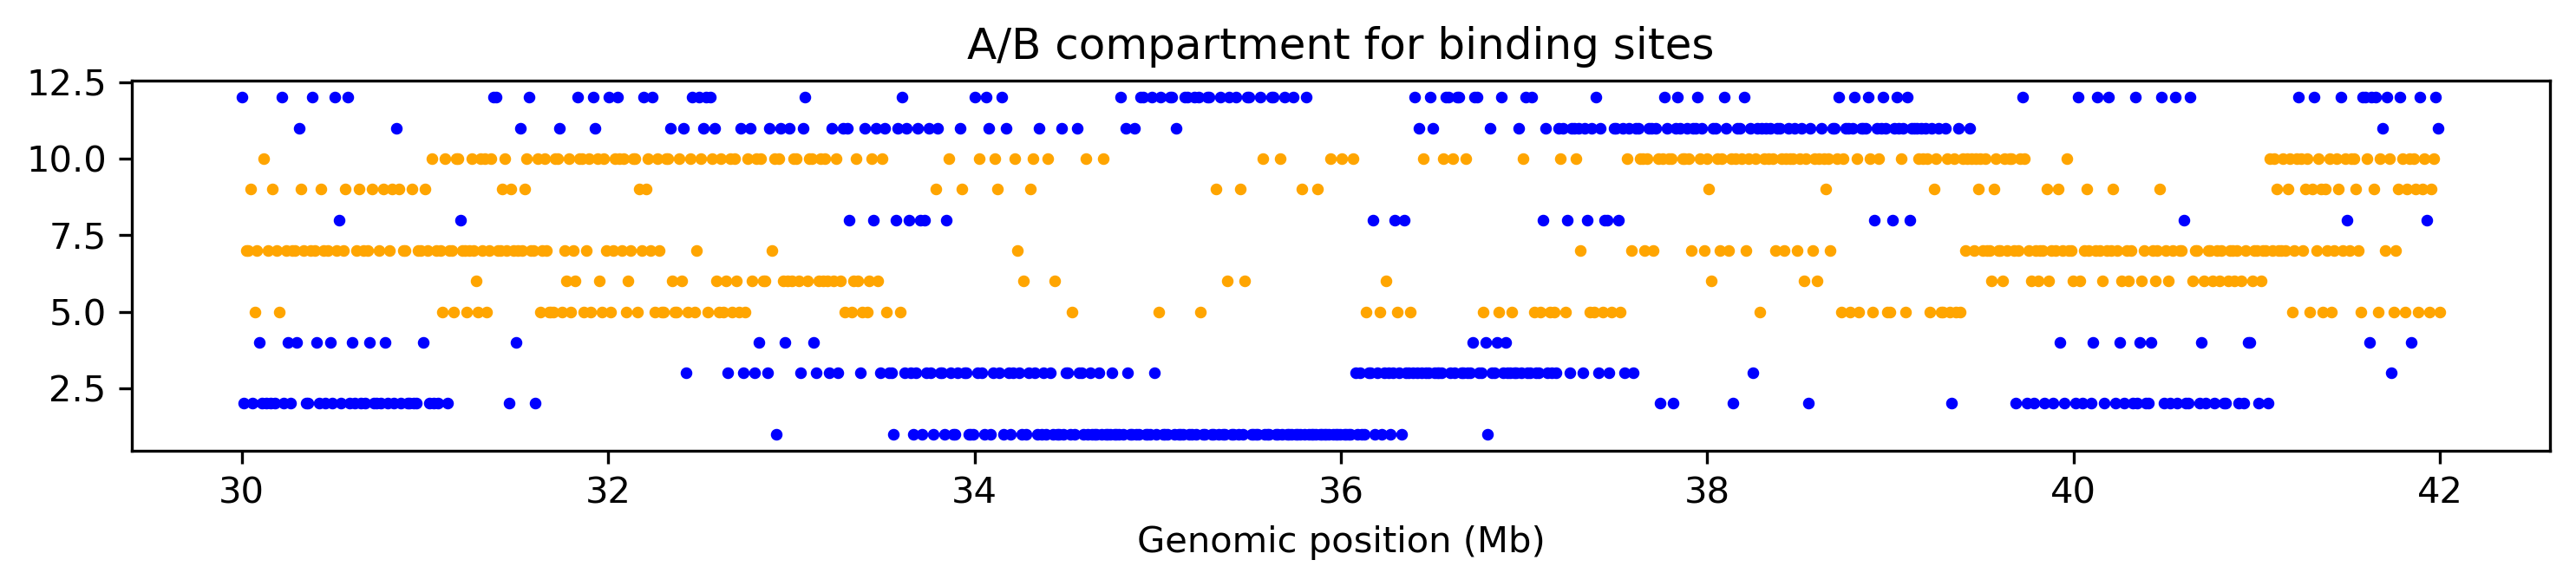

In [284]:
plt.figure(figsize=(10, 2), dpi = 300)
for i in range(chain_interaction_binary.shape[0]):
    beads_in_class = np.where(chain_interaction_binary[i,:]==1, 1, np.nan)
    if AB_binding_class_eigenvector[i] == 1:
        plt.scatter(x_uniform_scale, beads_in_class+i, color = "blue", s = 5)
    else:
        plt.scatter(x_uniform_scale, beads_in_class+i, color = "orange", s = 5)
plt.tight_layout()
plt.xlabel("Genomic position (Mb)")
plt.title("A/B compartment for binding sites")

Text(0.5, 1.0, 'A/B compartment for binding classes')

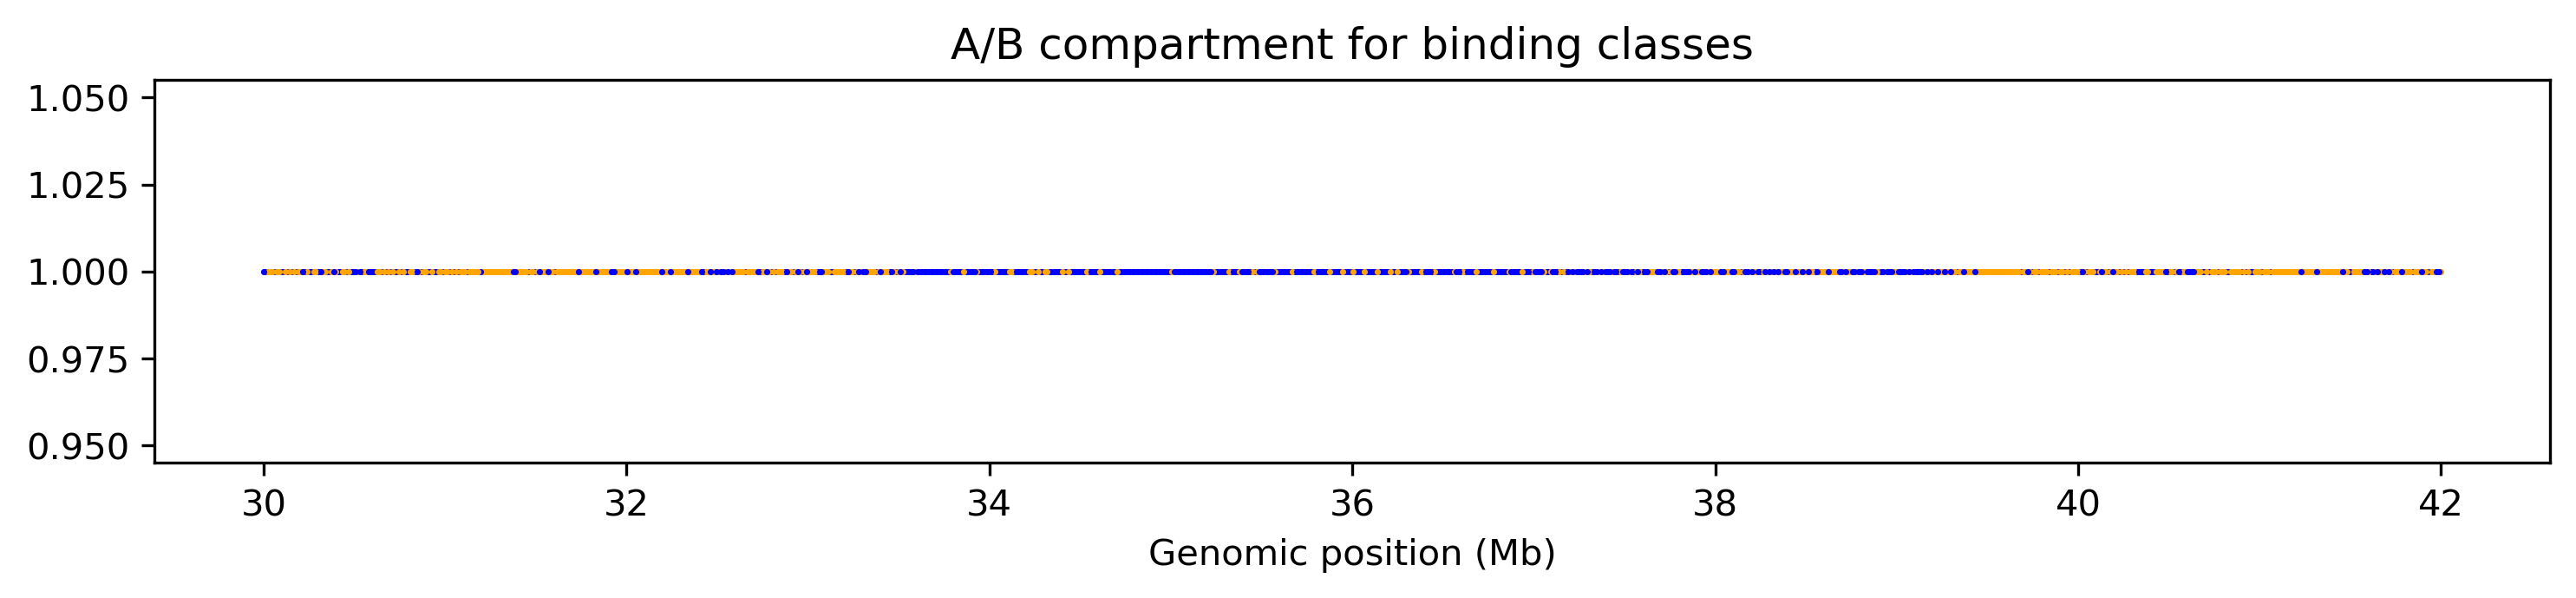

In [286]:
plt.figure(figsize=(10, 2), dpi = 300)
for i in range(chain_interaction_binary.shape[0]):
    beads_in_class = np.where(chain_interaction_binary[i,:]==1, 1, np.nan)
    if AB_binding_class_eigenvector[i] == 1:
        plt.scatter(x_uniform_scale, beads_in_class, color = "blue", s = 0.5)
    else:
        plt.scatter(x_uniform_scale, beads_in_class, color = "orange", s = 0.5)
plt.tight_layout()
plt.xlabel("Genomic position (Mb)")
plt.title("A/B compartment for binding classes")